In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 41.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 107.0 MB/s eta 0:00:0000:0100:01


In [ ]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10
from torchvision import transforms
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math
import torch.nn.functional as F

# Set seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

#  Setup GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# CIFAR-10 class names
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

#  Enhanced Data Loading with Subsetting
def load_data(classes=[0,1], max_samples_per_class=200, test_samples_per_class=50):
    """Load subset of CIFAR10 with specified classes and sample sizes"""
    transform = transforms.Compose([
        transforms.Grayscale(),
        transforms.Resize((8, 8)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    # Load full datasets
    trainset = CIFAR10('./data', train=True, download=True, transform=transform)
    testset = CIFAR10('./data', train=False, transform=transform)

    def filter_dataset(dataset, max_samples=None):
        x, y = [], []
        counts = {c:0 for c in classes}
        for img, label in dataset:
            if label in classes and counts[label] < (max_samples or float('inf')):
                x.append(img.view(-1))
                y.append(classes.index(label))
                counts[label] += 1
                if all(c >= (max_samples or float('inf')) for c in counts.values()):
                    break
        return torch.stack(x), torch.tensor(y)

    x_train, y_train = filter_dataset(trainset, max_samples_per_class)
    x_test, y_test = filter_dataset(testset, test_samples_per_class)

    print(f"Loaded {len(x_train)} training samples and {len(x_test)} test samples")
    print(f"Class distribution - Train: {np.bincount(y_train)}, Test: {np.bincount(y_test)}")

    return x_train, y_train, x_test, y_test, [cifar10_classes[c] for c in classes]

def pool_to_qubits(image, n_qubits):
    """Convert 8x8 image to n_qubits features using adaptive pooling"""
    img_2d = image.view(1, 8, 8)  # (1, H, W) for grayscale

    # Find the smallest (h, w) such that h * w >= n_qubits
    side = int(math.ceil(math.sqrt(n_qubits)))
    h, w = side, side
    while h * w < n_qubits:
        if h <= w:
            h += 1
        else:
            w += 1

    # Use adaptive pooling to reshape to (h, w)
    pooled = F.adaptive_avg_pool2d(img_2d, output_size=(h, w))
    flattened = pooled.view(-1)

    # Truncate or pad to exactly n_qubits
    if len(flattened) < n_qubits:
        padding = torch.zeros(n_qubits - len(flattened))
        return torch.cat([flattened, padding])
    return flattened[:n_qubits]


Using device: cuda


In [ ]:
# Enhanced Quantum Circuit
n_qubits = 8
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(image, weights):

    inputs=pool_to_qubits(image,n_qubits)

    # Enhanced feature embedding
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.RX(inputs[i], wires=i)
        qml.RZ(inputs[(i+1)%n_qubits], wires=i)

    # Two strong variational layers
    for layer in range(2):
        # Single-qubit rotations
        for i in range(n_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)

        # All-to-all entanglement
        for i in range(n_qubits):
            for j in range(i+1, min(i+3, n_qubits)):  # Limited connectivity
                qml.CRZ(weights[layer, i, j], wires=[i,j])

    # Final rotations
    for i in range(n_qubits):
        qml.RY(weights[-1, i, 0], wires=i)

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Enhanced Quantum Layer with GPU support
class QuantumLayer(nn.Module):
    def __init__(self, n_qubits):
        super().__init__()
        self.n_qubits = n_qubits
        self.weights = nn.Parameter(torch.rand(4, n_qubits, n_qubits, dtype=torch.float32))

    def forward(self, x):
        x = x.float().to(device)
        if len(x.shape) == 1:
            x = x.unsqueeze(0)

        batch_outputs = []
        for i in range(x.shape[0]):
            out = quantum_circuit(x[i].cpu(), self.weights.cpu())
            batch_outputs.append(torch.stack(out).float().to(device))

        return torch.stack(batch_outputs)

# Complete Hybrid Model
class QuantumClassifier(nn.Module):
    def __init__(self, n_qubits, n_classes):
        super().__init__()
        self.quantum = QuantumLayer(n_qubits)
        self.classical = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        ).to(device)

    def forward(self, x):
        x = x.float().to(device)
        x = self.quantum(x)
        return self.classical(x)


In [ ]:
#  Visualization and Evaluation Functions
def plot_confusion_matrix(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

def draw_quantum_circuit(model):
    print("\nQuantum Circuit Visualization:")
    try:
        # Get sample input and weights
        sample_input = torch.randn(n_qubits).cpu().numpy()
        weights = model.quantum.weights.detach().cpu().numpy()

        # Create a dummy circuit for visualization
        @qml.qnode(dev, interface="numpy")
        def circuit_to_draw(inputs, weights):
            # Simplified version for visualization
            for i in range(n_qubits):
                qml.RY(inputs[i], wires=i)
                qml.RZ(weights[0, i, 0], wires=i)
            for i in range(n_qubits-1):
                qml.CNOT(wires=[i, i+1])
            return qml.expval(qml.PauliZ(0))

        fig, ax = qml.draw_mpl(circuit_to_draw)(sample_input, weights)
        plt.title("Quantum Circuit Structure")
        plt.show()
    except Exception as e:
        print(f"Could not draw circuit: {e}")

def class_wise_accuracy(model, test_loader, class_names):
    model.eval()
    class_correct = [0] * len(class_names)
    class_total = [0] * len(class_names)

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            c = (preds == labels)

            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

    # Plot class-wise accuracy
    plt.figure(figsize=(10,5))
    plt.bar(class_names, [class_correct[i]/class_total[i] for i in range(len(class_names))])
    plt.title('Class-wise Accuracy')
    plt.xlabel('Class')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.show()


In [ ]:
def train_and_evaluate(classes=[0,1], train_samples=200, test_samples=50, epochs=15):
    # Load subsetted data
    x_train, y_train, x_test, y_test, class_names = load_data(
        classes=classes,
        max_samples_per_class=train_samples,
        test_samples_per_class=test_samples
    )

    # Data loaders
    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)
    test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=len(x_test))

    # Initialize model
    model = QuantumClassifier(n_qubits, len(classes)).to(device)
    opt = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    # Training loop
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()

            total_loss += loss.item()
            _, preds = torch.max(out, 1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        # Print training progress
        train_acc = correct / total
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} | Train Acc: {train_acc*100:.4f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        xb, yb = next(iter(test_loader))
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        preds = out.argmax(dim=1)
        test_acc = accuracy_score(yb.cpu(), preds.cpu())
        print(f"\nTest Accuracy: {test_acc*100:.4f}")

    # Visualizations
    plot_confusion_matrix(model, test_loader, class_names)
    draw_quantum_circuit(model)
    class_wise_accuracy(model, test_loader, class_names)

    return test_acc


Training on classes: ['airplane', 'cat']
Files already downloaded and verified
Loaded 2000 training samples and 400 test samples
Class distribution - Train: [1000 1000], Test: [200 200]
Epoch 1/15 | Loss: 38.1266 | Train Acc: 66.9000
Epoch 2/15 | Loss: 35.8872 | Train Acc: 70.2000
Epoch 3/15 | Loss: 35.9155 | Train Acc: 70.9500
Epoch 4/15 | Loss: 35.4113 | Train Acc: 71.8000
Epoch 5/15 | Loss: 36.0524 | Train Acc: 71.0000
Epoch 6/15 | Loss: 34.9625 | Train Acc: 71.4000
Epoch 7/15 | Loss: 34.5851 | Train Acc: 72.6000
Epoch 8/15 | Loss: 35.1710 | Train Acc: 71.2000
Epoch 9/15 | Loss: 35.6399 | Train Acc: 70.9500
Epoch 10/15 | Loss: 34.3530 | Train Acc: 72.1500
Epoch 11/15 | Loss: 35.1480 | Train Acc: 71.3500
Epoch 12/15 | Loss: 35.5738 | Train Acc: 71.4000
Epoch 13/15 | Loss: 34.8462 | Train Acc: 72.8500
Epoch 14/15 | Loss: 35.5968 | Train Acc: 71.4000
Epoch 15/15 | Loss: 35.4012 | Train Acc: 71.3000

Test Accuracy: 71.0000


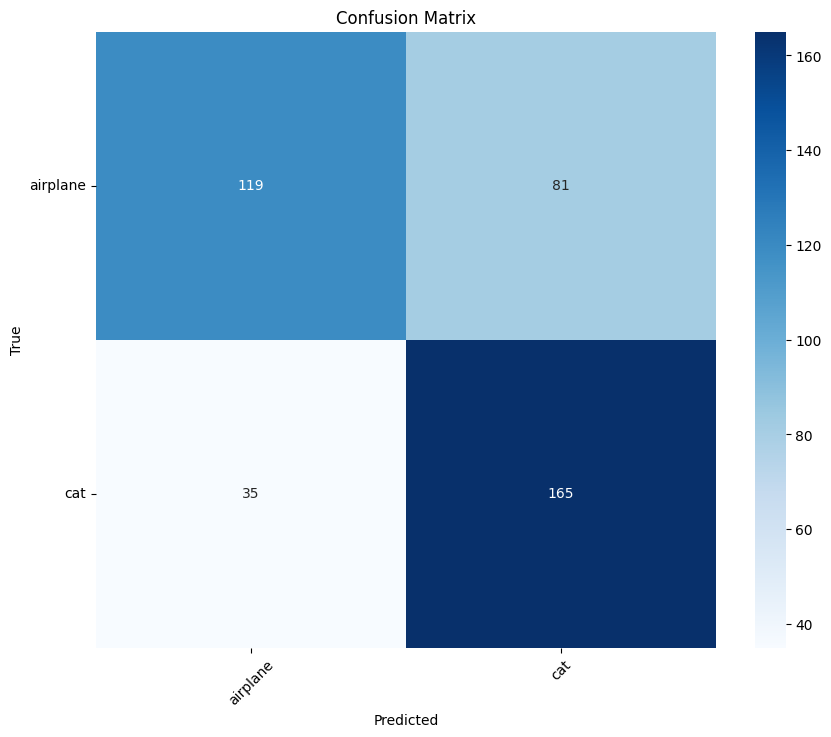


Classification Report:
              precision    recall  f1-score   support

    airplane       0.77      0.59      0.67       200
         cat       0.67      0.82      0.74       200

    accuracy                           0.71       400
   macro avg       0.72      0.71      0.71       400
weighted avg       0.72      0.71      0.71       400


Quantum Circuit Visualization:


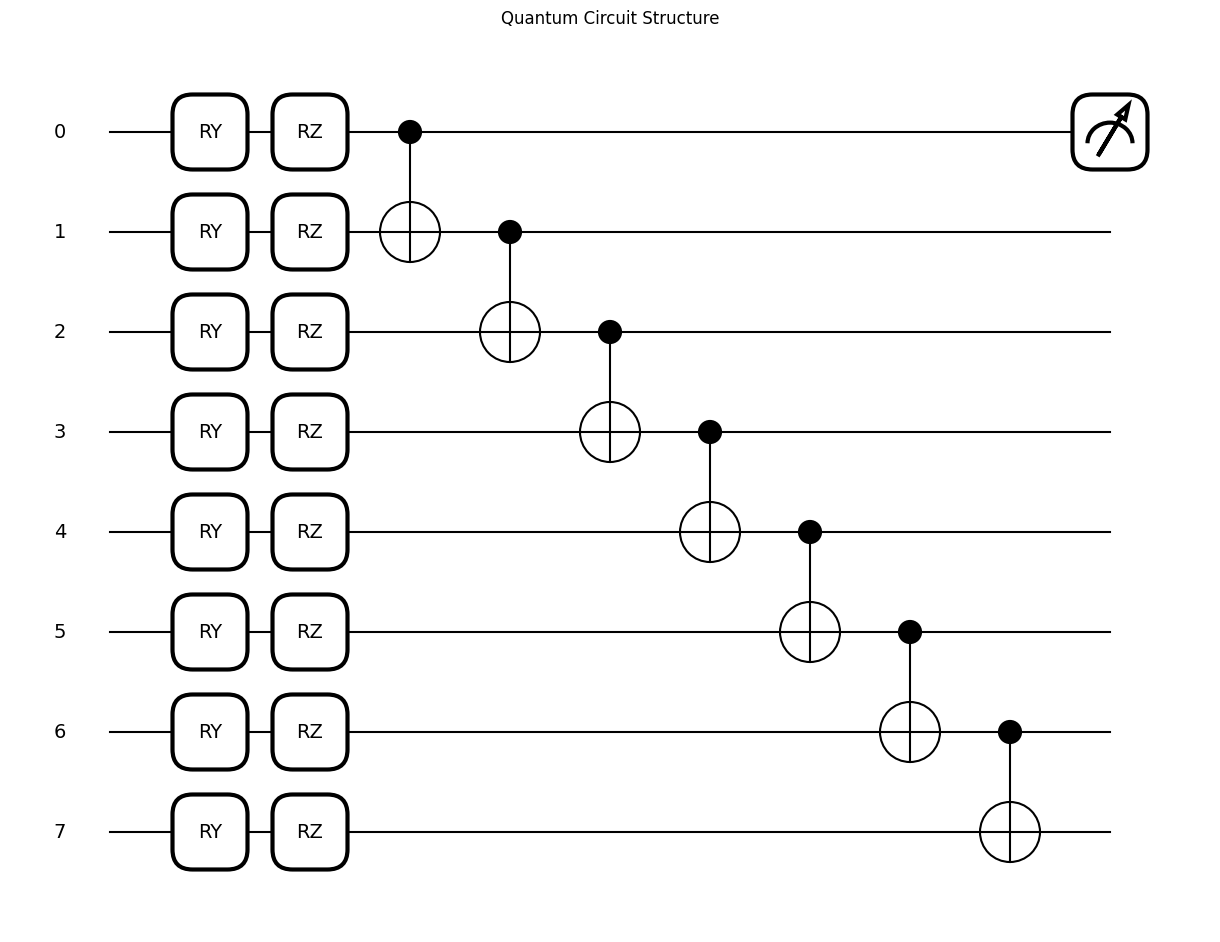

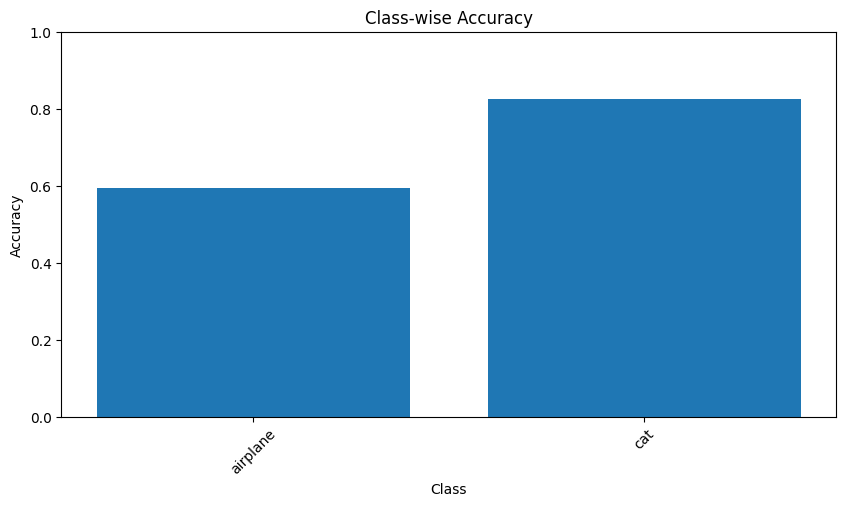


Training on classes: ['bird', 'horse', 'truck']
Files already downloaded and verified
Loaded 3000 training samples and 600 test samples
Class distribution - Train: [1000 1000 1000], Test: [200 200 200]
Epoch 1/15 | Loss: 94.6213 | Train Acc: 51.5333
Epoch 2/15 | Loss: 90.3372 | Train Acc: 53.5667
Epoch 3/15 | Loss: 87.7432 | Train Acc: 55.5333
Epoch 4/15 | Loss: 85.7075 | Train Acc: 56.5000
Epoch 5/15 | Loss: 85.0715 | Train Acc: 57.7667
Epoch 6/15 | Loss: 84.9913 | Train Acc: 58.2000
Epoch 7/15 | Loss: 83.3565 | Train Acc: 59.5667
Epoch 8/15 | Loss: 83.7119 | Train Acc: 58.6000
Epoch 9/15 | Loss: 83.6917 | Train Acc: 58.4333
Epoch 10/15 | Loss: 84.2153 | Train Acc: 57.5333
Epoch 11/15 | Loss: 82.7843 | Train Acc: 59.8333
Epoch 12/15 | Loss: 83.1078 | Train Acc: 59.2667
Epoch 13/15 | Loss: 82.2299 | Train Acc: 59.5333
Epoch 14/15 | Loss: 81.4446 | Train Acc: 60.8333
Epoch 15/15 | Loss: 82.0131 | Train Acc: 61.0667

Test Accuracy: 61.6667


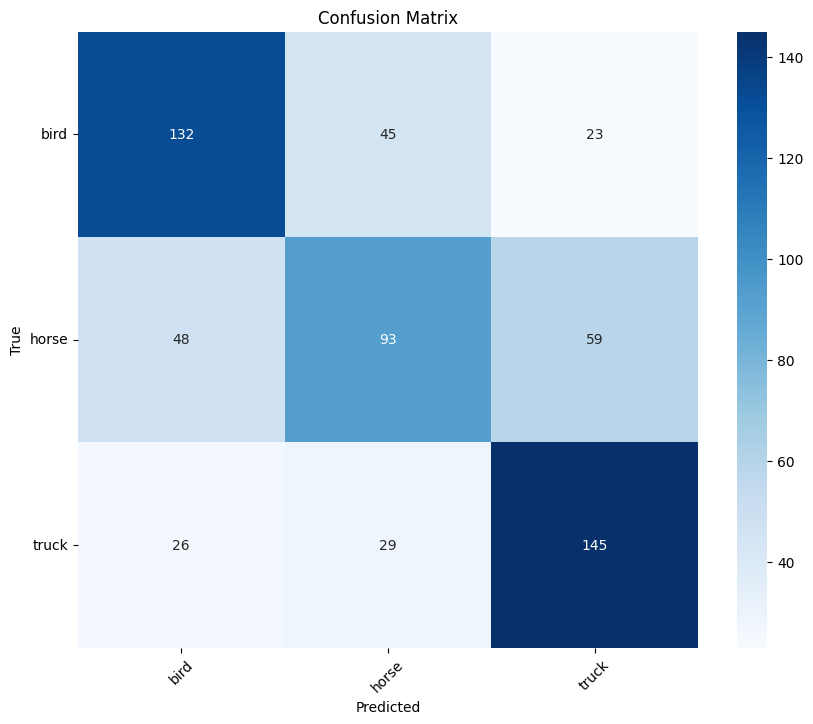


Classification Report:
              precision    recall  f1-score   support

        bird       0.64      0.66      0.65       200
       horse       0.56      0.47      0.51       200
       truck       0.64      0.72      0.68       200

    accuracy                           0.62       600
   macro avg       0.61      0.62      0.61       600
weighted avg       0.61      0.62      0.61       600


Quantum Circuit Visualization:


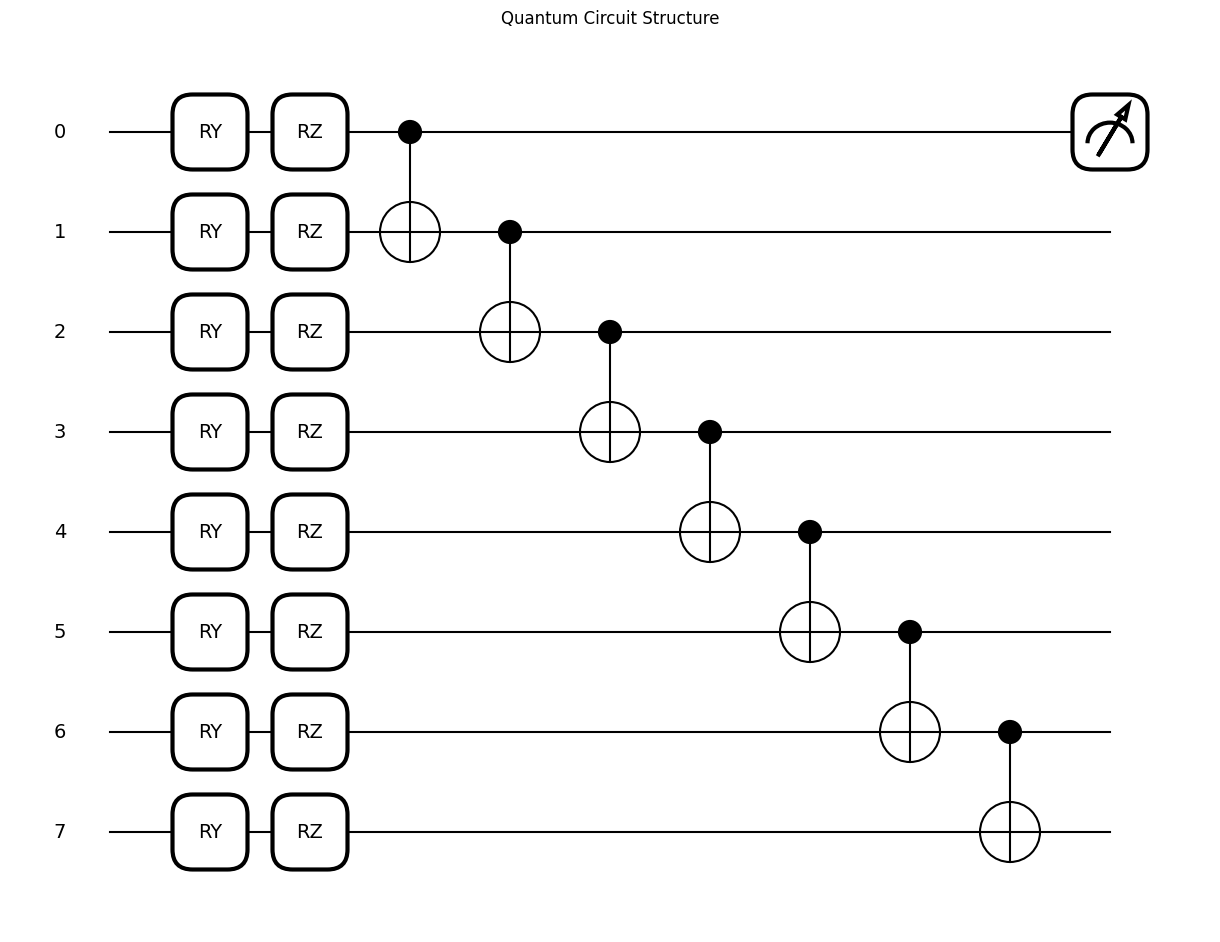

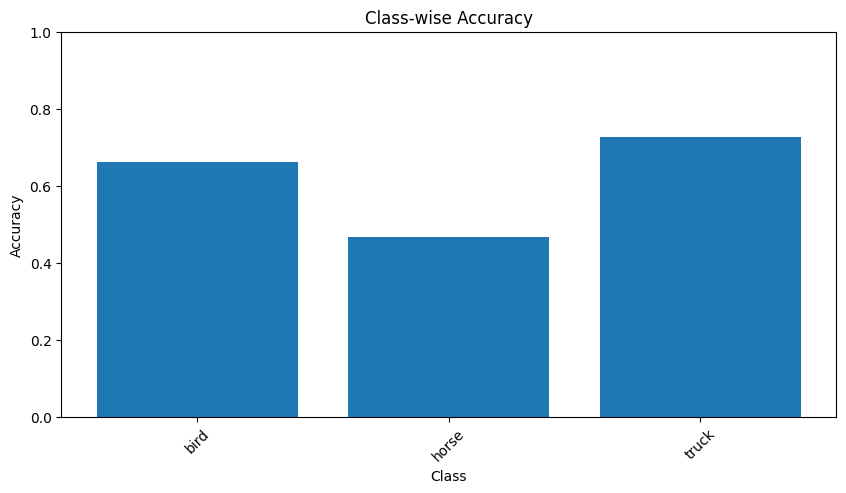


Training on classes: ['bird', 'deer', 'dog', 'horse', 'truck']
Files already downloaded and verified
Loaded 5000 training samples and 1000 test samples
Class distribution - Train: [1000 1000 1000 1000 1000], Test: [200 200 200 200 200]
Epoch 1/15 | Loss: 235.1147 | Train Acc: 33.6400
Epoch 2/15 | Loss: 230.6488 | Train Acc: 35.8400
Epoch 3/15 | Loss: 228.9832 | Train Acc: 35.9800
Epoch 4/15 | Loss: 226.1585 | Train Acc: 38.9600
Epoch 5/15 | Loss: 225.9618 | Train Acc: 38.0800
Epoch 6/15 | Loss: 225.3454 | Train Acc: 38.8000
Epoch 7/15 | Loss: 225.3614 | Train Acc: 39.0400
Epoch 8/15 | Loss: 223.7340 | Train Acc: 39.4800
Epoch 9/15 | Loss: 223.8459 | Train Acc: 39.2400
Epoch 10/15 | Loss: 224.4261 | Train Acc: 38.2400
Epoch 11/15 | Loss: 223.6294 | Train Acc: 39.7200
Epoch 12/15 | Loss: 224.9072 | Train Acc: 38.2000
Epoch 13/15 | Loss: 223.5522 | Train Acc: 39.7600
Epoch 14/15 | Loss: 223.4738 | Train Acc: 39.5000
Epoch 15/15 | Loss: 222.9218 | Train Acc: 39.3200

Test Accuracy: 40.700

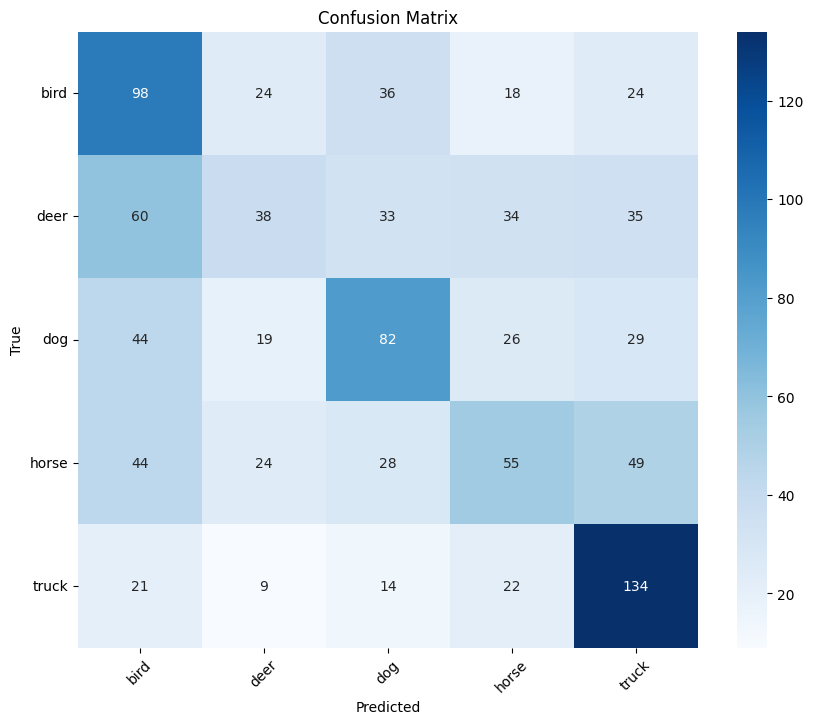


Classification Report:
              precision    recall  f1-score   support

        bird       0.37      0.49      0.42       200
        deer       0.33      0.19      0.24       200
         dog       0.42      0.41      0.42       200
       horse       0.35      0.28      0.31       200
       truck       0.49      0.67      0.57       200

    accuracy                           0.41      1000
   macro avg       0.39      0.41      0.39      1000
weighted avg       0.39      0.41      0.39      1000


Quantum Circuit Visualization:


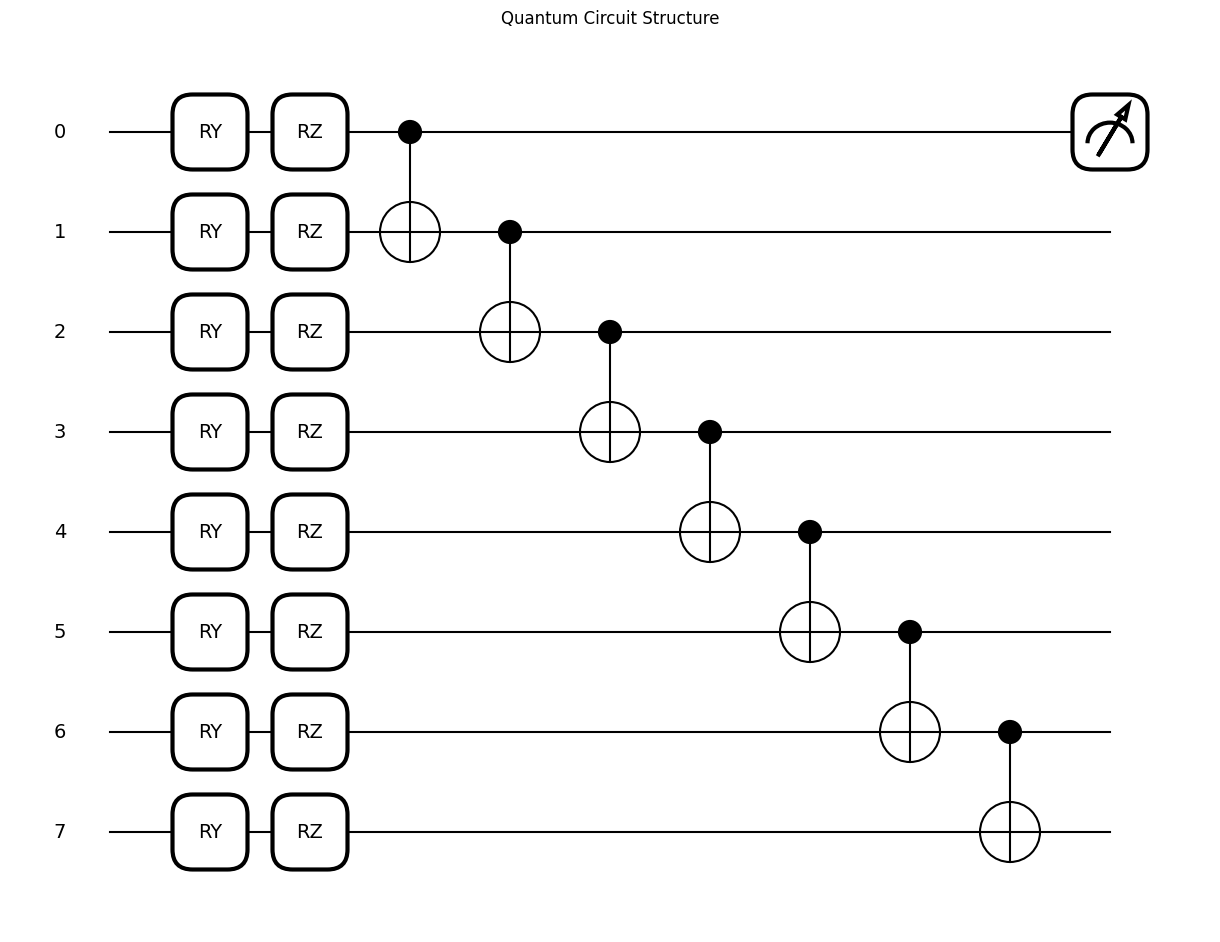

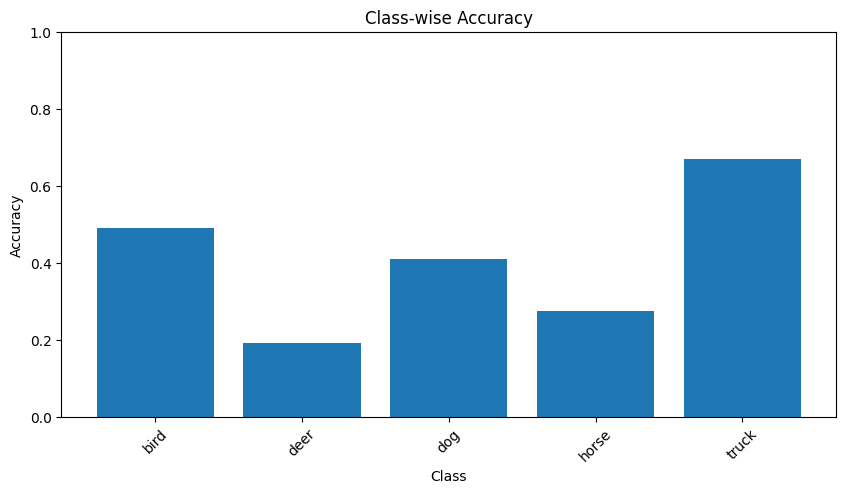


Final Results:
Classes ['airplane', 'cat']: Accuracy = 71.0000
Classes ['bird', 'horse', 'truck']: Accuracy = 61.6667
Classes ['bird', 'deer', 'dog', 'horse', 'truck']: Accuracy = 40.7000


In [ ]:
if __name__ == "__main__":
    # Try different class combinations
    class_combinations = [
        [0, 3],           # Binary
        [2,7,9],        # 3-class
        [2,4,5,7,9],  # 5-class
    ]

    results = {}
    for classes in class_combinations:
        print(f"\nTraining on classes: {[cifar10_classes[c] for c in classes]}")
        acc = train_and_evaluate(
            classes=classes,
            train_samples=1000,
            test_samples=200,
            epochs=15
        )
        results[tuple(classes)] = acc

    print("\nFinal Results:")
    for classes, acc in results.items():
        print(f"Classes {[cifar10_classes[c] for c in classes]}: Accuracy = {acc*100:.4f}")